In [ ]:
%cd /content/tng-anisotropy-atlas

[Errno 2] No such file or directory: '/content/tng-anisotropy-atlas'
/content


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def make_toy_halo(n_sat=500, r_min=0.05, r_max=1.0, beta_target=0.0, seed=42):
    """
    Generate a fake halo of 'satellites' around an origin,
    with velocity anisotropy controlled by beta_target.

    beta = 1 - sigma_t^2 / (2 sigma_r^2)
    so we choose: sigma_r = 1 (units), sigma_t = sqrt(2(1-beta)) * sigma_r
    """
    rng = np.random.default_rng(seed)

    # --- positions: uniform number density between r_min and r_max
    r = rng.uniform(r_min**3, r_max**3, n_sat)**(1/3)
    # random directions on a sphere
    cos_theta = rng.uniform(-1, 1, n_sat)
    sin_theta = np.sqrt(1 - cos_theta**2)
    phi = rng.uniform(0, 2*np.pi, n_sat)
    x = r * sin_theta * np.cos(phi)
    y = r * sin_theta * np.sin(phi)
    z = r * cos_theta
    pos = np.column_stack([x, y, z])

    # --- velocities: dispersions set by the target beta
    sigma_r = 1.0
    sigma_t = np.sqrt(2.0 * (1.0 - beta_target)) * sigma_r

    # unit vector pointing radially outward from origin, per satellite
    r_hat = pos / np.linalg.norm(pos, axis=1, keepdims=True)

    # build a random unit vector perpendicular to r_hat (tangential dir 1)
    a = rng.normal(size=(n_sat, 3))
    a -= (a * r_hat).sum(axis=1, keepdims=True) * r_hat   # remove radial part
    a_hat = a / np.linalg.norm(a, axis=1, keepdims=True)

    # tangential dir 2 = perpendicular to both (cross product)
    b_hat = np.cross(r_hat, a_hat)

    # draw velocity components: radial + two tangential
    v_r   = rng.normal(0, sigma_r, n_sat)
    v_t1  = rng.normal(0, sigma_t / np.sqrt(2), n_sat)
    v_t2  = rng.normal(0, sigma_t / np.sqrt(2), n_sat)

    # total velocity = sum of the three orthogonal pieces
    vel = (v_r[:, None] * r_hat +
           v_t1[:, None] * a_hat +
           v_t2[:, None] * b_hat)

    return pos, vel

positions shape: (500, 3)
velocities shape: (500, 3)


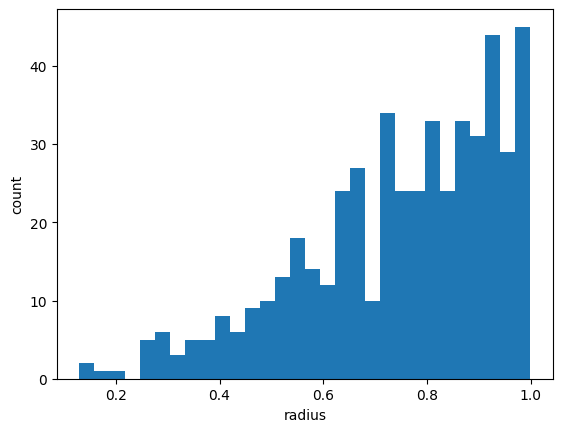

In [ ]:
pos, vel = make_toy_halo(beta_target=0.0, seed=1)

print("positions shape:", pos.shape)   # should be (500, 3)
print("velocities shape:", vel.shape)  # should be (500, 3)

# quick look: radial distance histogram
r = np.linalg.norm(pos, axis=1)
plt.hist(r, bins=30)
plt.xlabel("radius"); plt.ylabel("count")
plt.show()

In [ ]:
def radial_tangential_split(pos, vel):
    """
    Decompose each satellite's velocity into radial and tangential parts
    relative to the halo center (origin).

    Returns r, v_r (radial component), v_t (tangential SPEED = |tangential vector|)
    """
    r = np.linalg.norm(pos, axis=1)                    # distance from origin
    r_hat = pos / r[:, None]                           # unit vector: origin -> satellite
    v_r = (vel * r_hat).sum(axis=1)                    # projection onto radial dir
    v_t_vec = vel - v_r[:, None] * r_hat               # what's left is tangential
    v_t = np.linalg.norm(v_t_vec, axis=1)              # tangential speed
    return r, v_r, v_t


def beta_profile(pos, vel, n_bins=6, n_min=20):
    r, v_r, v_t = radial_tangential_split(pos, vel)

    edges = np.quantile(r, np.linspace(0, 1, n_bins + 1))   # equal-count bins
    edges[0], edges[-1] = r.min(), r.max()                  # guard edges

    r_centers, betas, beta_errs, ns = [], [], [], []
    for i in range(n_bins):
        sel = (r >= edges[i]) & (r < edges[i + 1] if i < n_bins - 1 else r <= edges[i + 1])
        n = sel.sum()
        if n < n_min:
            continue
        # ... rest identical to before ...                                 # too few: skip, don't fake precision

        vr, vt = v_r[sel], v_t[sel]
        sr2 = np.var(vr, ddof=1)        # radial: signed -> variance is correct
        st2 = np.mean(vt**2)            # tangential: magnitude -> second moment!

        beta = 1.0 - st2 / (2.0 * sr2)

        # error propagation (delta method): beta = 1 - st2/(2 sr2)
        # standard errors of the variances: var * sqrt(2/(n-1))
        sr2_err = sr2 * np.sqrt(2.0 / (n - 1))
        st2_err = st2 / np.sqrt(n)              # second moment of Rayleigh: err = sigma_t^2/sqrt(n)
        beta_err = np.sqrt((st2_err / (2 * sr2))**2 +
                 (st2 * sr2_err / (2 * sr2**2))**2)

        r_centers.append(0.5 * (edges[i] + edges[i + 1]))
        betas.append(beta)
        beta_errs.append(beta_err)
        ns.append(n)

    return (np.array(r_centers), np.array(betas),
            np.array(beta_errs), np.array(ns))

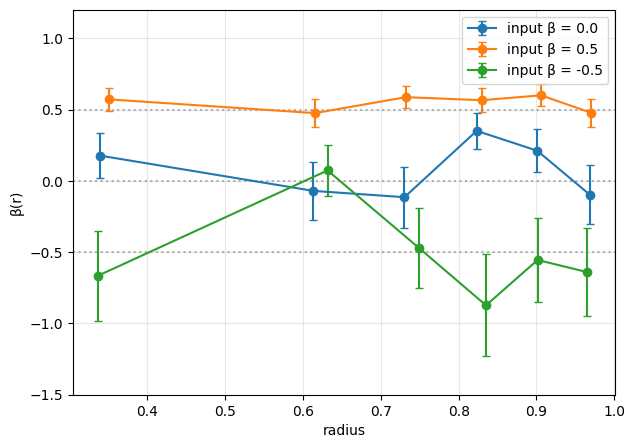

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for beta_in, seed in [(0.0, 1), (0.5, 2), (-0.5, 3)]:
    pos, vel = make_toy_halo(beta_target=beta_in, seed=seed)
    rc, beta, beta_err, n = beta_profile(pos, vel, n_bins=6, n_min=20)
    ax.errorbar(rc, beta, yerr=beta_err, marker='o', capsize=3,
                label=f'input β = {beta_in}')

for b in [0.0, 0.5, -0.5]:
    ax.axhline(b, color='gray', ls=':', alpha=0.6)   # true values

ax.set_xlabel('radius'); ax.set_ylabel('β(r)')
ax.set_ylim(-1.5, 1.2)
ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [ ]:
def ensemble_test(beta_in, n_real=30, n_sat=500, n_bins=6, n_min=20):
    """Run many independent toy halos, average recovered beta over radii."""
    vals = []
    for i in range(n_real):
        pos, vel = make_toy_halo(beta_target=beta_in, seed=1000 + i)
        rc, b, be, n = beta_profile(pos, vel, n_bins=n_bins, n_min=n_min)
        vals.append(np.mean(b))
    vals = np.array(vals)
    return vals.mean(), vals.std() / np.sqrt(n_real)

for beta_in in [0.0, 0.5, -0.5]:
    m, se = ensemble_test(beta_in)
    offset = (m - beta_in) / se          # how many standard errors from truth?
    print(f"input β={beta_in:+.1f} -> recovered {m:+.3f} ± {se:.3f}  "
          f"(offset = {offset:+.1f}σ)")

input β=+0.0 -> recovered -0.011 ± 0.013  (offset = -0.9σ)
input β=+0.5 -> recovered +0.494 ± 0.006  (offset = -0.9σ)
input β=-0.5 -> recovered -0.517 ± 0.019  (offset = -0.9σ)


In [ ]:
pos, vel = make_toy_halo(beta_target=0.0, seed=1)
rc, b, be, n = beta_profile(pos, vel, n_bins=6)
print("satellites per bin:", n)

satellites per bin: [84 83 83 83 83 84]


In [ ]:
def make_toy_halo_v2(n_sat=500, r_min=0.05, r_max=1.0, beta_of_r=None, seed=42):
    """Toy halo where anisotropy varies with radius via beta_of_r(r)."""
    rng = np.random.default_rng(seed)

    # positions: same as v1 (uniform in volume)
    r = rng.uniform(r_min**3, r_max**3, n_sat)**(1/3)
    cos_theta = rng.uniform(-1, 1, n_sat)
    sin_theta = np.sqrt(1 - cos_theta**2)
    phi = rng.uniform(0, 2*np.pi, n_sat)
    pos = np.column_stack([r * sin_theta * np.cos(phi),
                           r * sin_theta * np.sin(phi),
                           r * cos_theta])

    # orthogonal unit vectors per satellite
    r_hat = pos / np.linalg.norm(pos, axis=1, keepdims=True)
    a = rng.normal(size=(n_sat, 3))
    a -= (a * r_hat).sum(axis=1, keepdims=True) * r_hat
    a_hat = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_hat = np.cross(r_hat, a_hat)

    # per-satellite tangential dispersion, evaluated at ITS OWN radius
    sigma_r = 1.0
    beta_r = beta_of_r(r) if beta_of_r is not None else np.zeros(n_sat)
    sigma_t = np.sqrt(2.0 * (1.0 - beta_r)) * sigma_r

    v_r  = rng.normal(0, sigma_r, n_sat)
    v_t1 = rng.normal(0.0, sigma_t / np.sqrt(2))   # array sigma: numpy draws per-element
    v_t2 = rng.normal(0.0, sigma_t / np.sqrt(2))

    vel = (v_r[:, None] * r_hat +
           v_t1[:, None] * a_hat +
           v_t2[:, None] * b_hat)
    return pos, vel

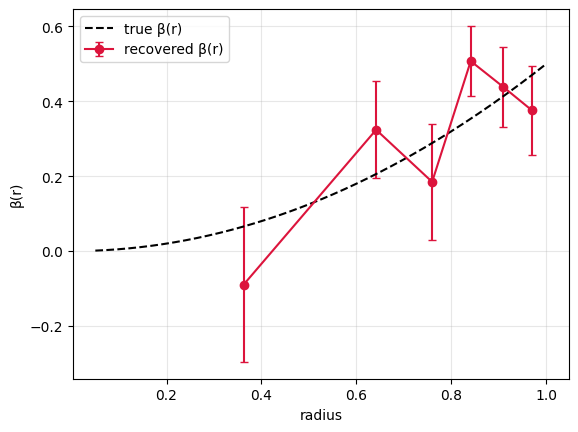

In [ ]:
beta_fn = lambda r: 0.5 * (r / 1.0)**2   # 0 at center -> 0.5 at edge (real-halo-like)

pos, vel = make_toy_halo_v2(beta_of_r=beta_fn, seed=7)
rc, beta, beta_err, n = beta_profile(pos, vel, n_bins=6, n_min=20)

r_fine = np.linspace(0.05, 1.0, 200)
plt.errorbar(rc, beta, yerr=beta_err, marker='o', capsize=3,
             label='recovered β(r)', color='crimson')
plt.plot(r_fine, beta_fn(r_fine), 'k--', label='true β(r)')
plt.xlabel('radius'); plt.ylabel('β(r)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()